In [1]:
import numpy as np
import shap
import matplotlib.pyplot as plt
import os

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
ref_source    = 'GEFSv12'
experiment='EX29'
region_name='CONUS'

In [3]:
import pandas as pd

# frequency of 7 days ensures you start exactly at 2000-01-05
dates = pd.date_range(start='2000-01-05', end='2019-12-25', freq='7D')

print(dates)

DatetimeIndex(['2000-01-05', '2000-01-12', '2000-01-19', '2000-01-26',
               '2000-02-02', '2000-02-09', '2000-02-16', '2000-02-23',
               '2000-03-01', '2000-03-08',
               ...
               '2019-10-23', '2019-10-30', '2019-11-06', '2019-11-13',
               '2019-11-20', '2019-11-27', '2019-12-04', '2019-12-11',
               '2019-12-18', '2019-12-25'],
              dtype='datetime64[ns]', length=1043, freq='7D')


In [4]:
from datetime import date, timedelta, datetime

def find_sample_indices_from_date(target, 
                                  start_date=date(2018,1,3), 
                                  n_realizations=11):
    """
    Given a target date (string "MM-DD-YYYY" or a date), 
    return the list of sample indices (0-based) corresponding 
    to the nearest weekly date in the Jan 3 2018→Dec 25 2019 series.
    """
    # parse target
    if isinstance(target, str):
        target = datetime.strptime(target, "%m-%d-%Y").date()
    elif isinstance(target, datetime):
        target = target.date()

    # build the weekly dates
    dates = []
    cur = start_date
    while cur <= date(2019,12,25):
        dates.append(cur)
        cur += timedelta(weeks=1)

    # find which week is closest
    week_idx = min(range(len(dates)), key=lambda i: abs(dates[i] - target))

    # compute the first sample index for that week
    first_sample = week_idx * n_realizations
    samples = list(range(first_sample, first_sample + n_realizations))

    # also return the exact date matched
    matched_date = dates[week_idx]
    return matched_date, samples

# example
matched_date, idxs = find_sample_indices_from_date("08-21-2019")
print(f"Input date:    2019-08-21")
print(f"Matched week:  {matched_date.isoformat()}")
print(f"Sample indices (0-based): {idxs}")
print(f"Sample numbers (1-based): {[i+1 for i in idxs]}")


Input date:    2019-08-21
Matched week:  2019-08-21
Sample indices (0-based): [935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945]
Sample numbers (1-based): [936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946]


In [5]:
def return_data_dir(week_lead, ref_source,region_name):
    return (f'Data/model_npy_input_data/{region_name}/Wk{week_lead}_EX_input_data' if ref_source == 'GEFSv12' else  f'Data/{model_npy_input_data}/{region_name}/Wk{week_lead}_ECMWF_EX_input_data')

def return_channel_names(week_lead, experiment):
    #feature channel names (predictors)
    with open(f"channel_list_information/Wk{week_lead}/{experiment}_RZSM_channel_list.txt") as f:
        names = [line.strip() for line in f]
    names = [s.split()[-1] for s in names]
    print(names)
    return names

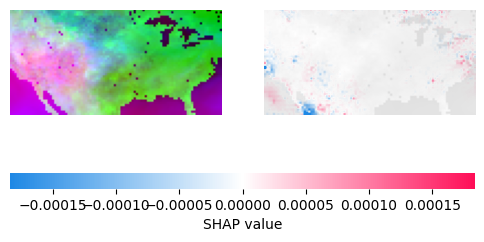

In [21]:


# 0) Initialize SHAP’s JS for interactive image plots
shap.initjs()

# 1) Load one of your saved runs’ SHAP values and the corresponding test data
week_lead = 2
seed      = 225
K         = 500
base_dir  = f"Data/shap_tests/Wk{week_lead}"
run_dir   = os.path.join(base_dir, f"K{K}_background_gradient_explainer")

# SHAP values shape: (N_test, H, W, C)
shap_values = np.load(os.path.join(run_dir, "shap_values.npy"))

# Load your test inputs (must match the channels used for SHAP)
X_test = np.load(
    f"{return_data_dir(week_lead, ref_source, region_name)}/"
    f"{experiment}_RZSM_testing_input.npy"
)  # shape (N_test, H, W, C_max)

# 2) Select a single sample index to visualize
sample_idx = 0

# Extract the SHAP map and the corresponding image
sv_sample = shap_values[sample_idx:sample_idx+1]     # shape (1, H, W, C)
x_sample  = X_test[sample_idx:sample_idx+1, : ,: , :sv_sample.shape[-1]]  # same shape

# 3) Produce the image plot
# This will overlay the per-pixel SHAP attributions on your input image.
shap.image_plot(
    sv_sample,
    x_sample,
    show=True   # for notebooks this pops up the interactive widget
)

# # 4) (Optional) If you'd prefer a matplotlib static display:
# plt.figure(figsize=(6,6))
# shap.image_plot(sv_sample, x_sample, show=False)
# plt.title(f"SHAP Image Plot (sample {sample_idx}, lead={week_lead}, seed={seed}, K={K})")
# plt.tight_layout()
# plt.show()


['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'pwat_ref_lead1', 'spfh_ref_lead1', 'tmax_ref_lead1', 'diff_temp_ref_lead1', 'z200_ref_lead1']


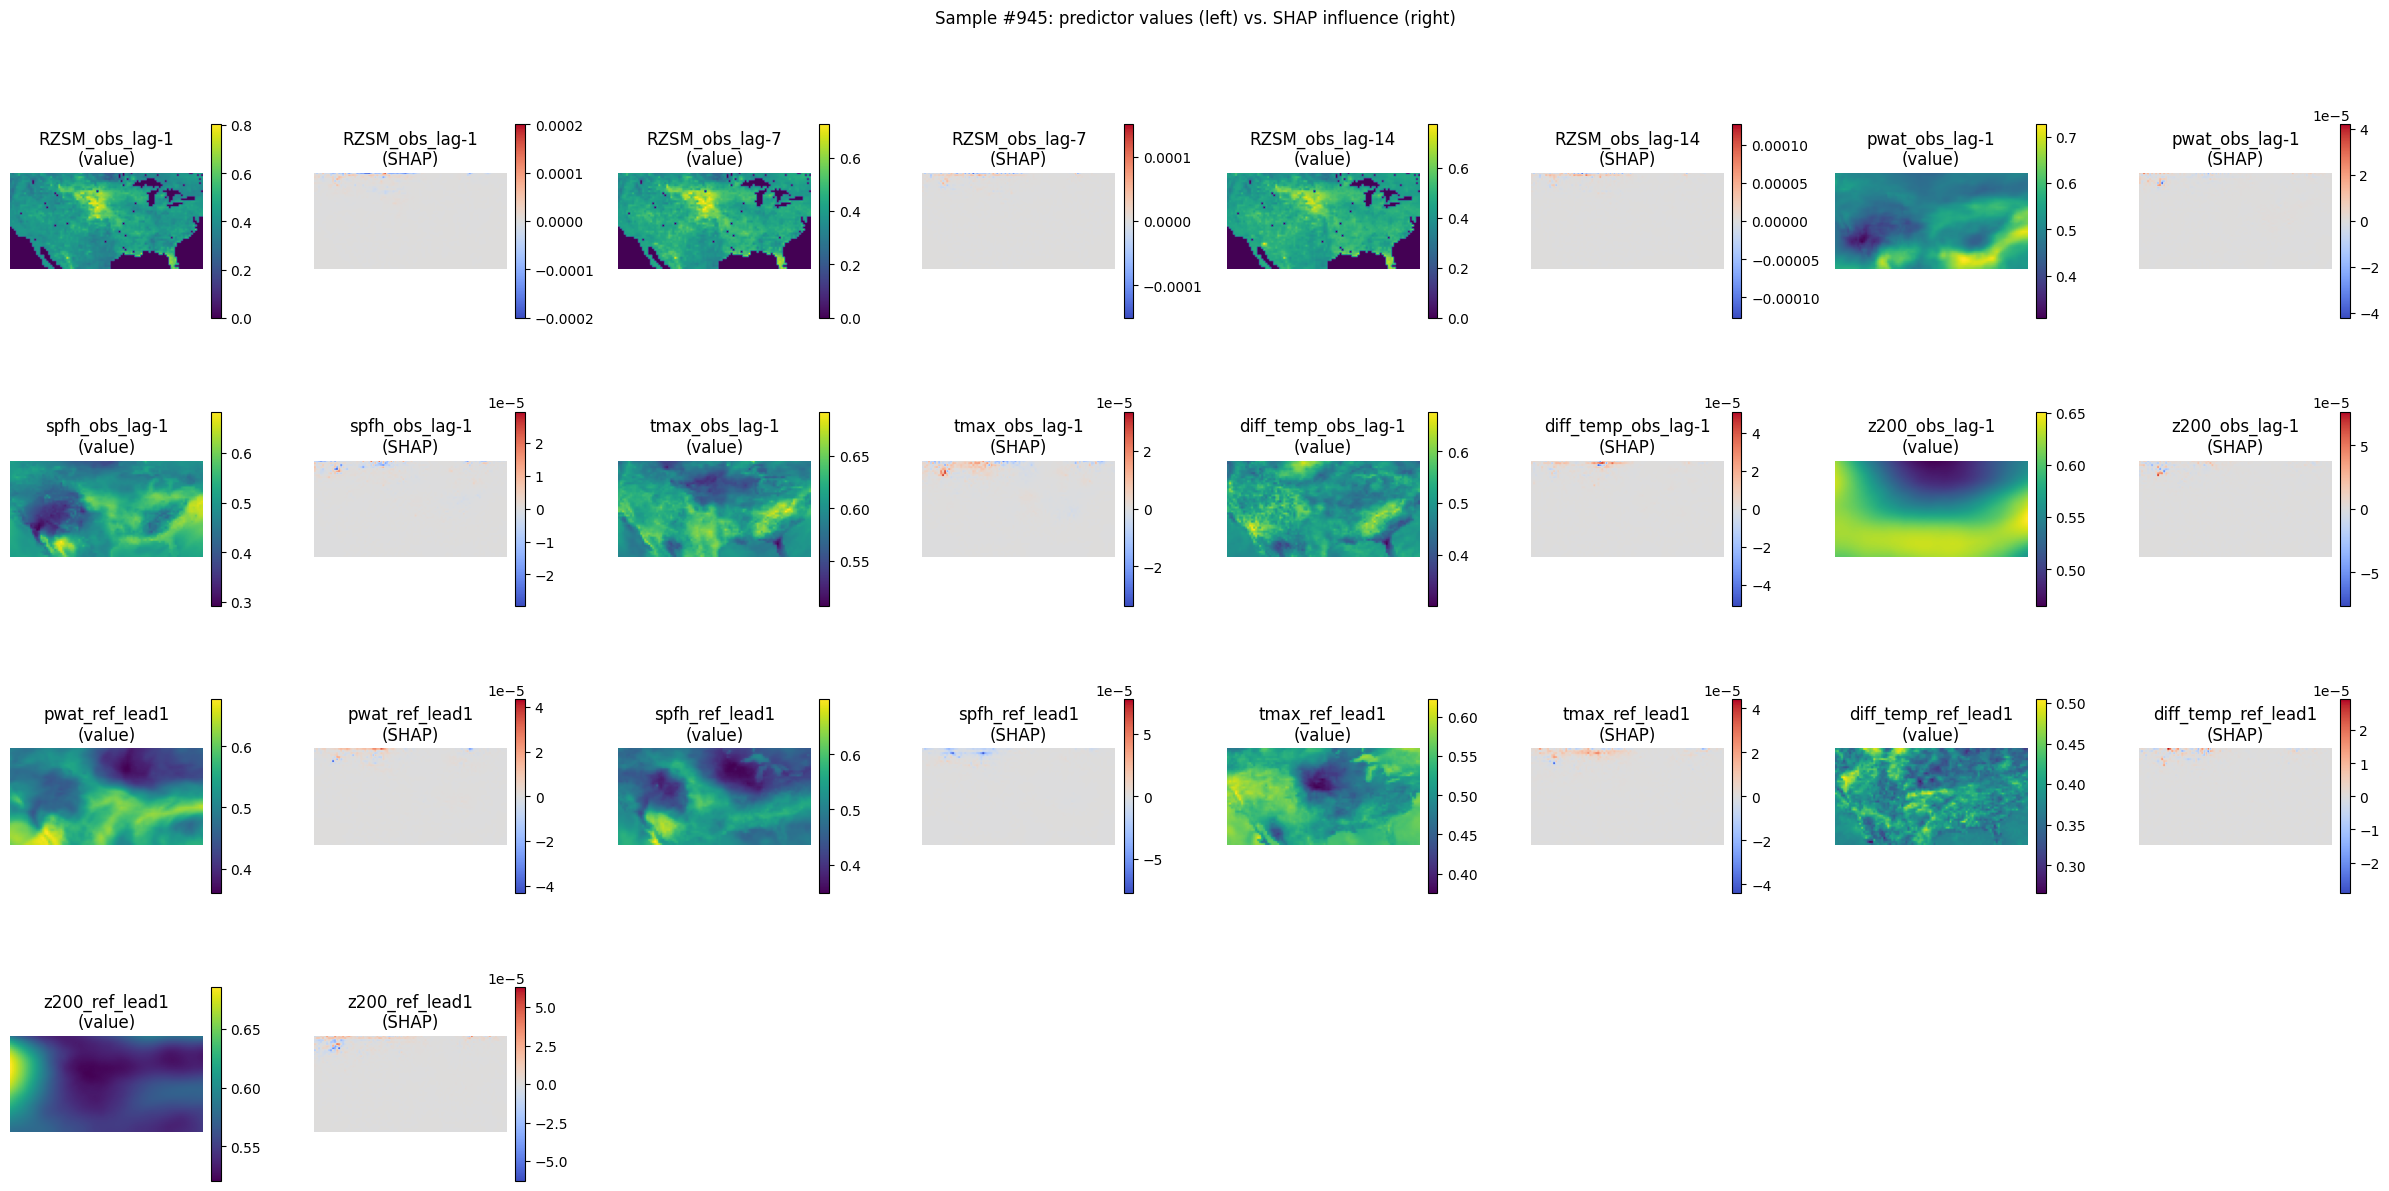

In [11]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import shap

# 1) Load one sample’s SHAP and input
week_lead = 1
seed      = 225
K         = 500
sample_idx = idxs[10]

# paths
base_dir = f"Data/shap_tests/Wk{week_lead}"
run_dir  = os.path.join(base_dir, f"K{K}_background_gradient_explainer")

# load
shap_values = np.load(os.path.join(run_dir,"shap_values.npy"))  # (N_test, H, W, C)
X_test      = np.load(f"{return_data_dir(week_lead, ref_source,region_name)}/"
                      f"{experiment}_RZSM_testing_input.npy")  # (N_test,H,W,C_max)

# only keep the first C channels that match shap_values
_, H, W, C = shap_values.shape
sv_sample = shap_values[sample_idx]      # (H, W, C)
x_sample  = X_test[sample_idx, : ,: , :C] # (H, W, C)

channel_names = return_channel_names(week_lead, experiment)

# 2) Set up a grid: two columns per channel (value | SHAP), wrap as needed
ncols = 4
nrows = math.ceil(C/ncols)
fig, axes = plt.subplots(nrows, ncols*2, figsize=(2*ncols*3, nrows*3))

for i, name in enumerate(channel_names):
    r = i // ncols
    c = i % ncols

    # plot the raw input channel
    ax_val = axes[r, 2*c]
    im1 = ax_val.imshow(x_sample[:,:,i], cmap="viridis")
    ax_val.set_title(f"{name}\n(value)")
    ax_val.axis("off")
    fig.colorbar(im1, ax=ax_val, fraction=0.046, pad=0.04)

    # plot the corresponding SHAP map
    ax_sh = axes[r, 2*c+1]
    im2 = ax_sh.imshow(sv_sample[:,:,i], cmap="coolwarm", vmin=-np.max(np.abs(sv_sample[:,:,i])), vmax=np.max(np.abs(sv_sample[:,:,i])))
    ax_sh.set_title(f"{name}\n(SHAP)")
    ax_sh.axis("off")
    fig.colorbar(im2, ax=ax_sh, fraction=0.046, pad=0.04)

# hide any unused subplots
total_plots = nrows * ncols * 2
for j in range(C*2, total_plots):
    fig.delaxes(axes.flat[j])

plt.suptitle(f"Sample #{sample_idx}: predictor values (left) vs. SHAP influence (right)", y=1.02)
plt.tight_layout()
plt.show()
